In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
import datetime
from ipywidgets import interact, FloatSlider
import seaborn as sns

In [7]:
data = "data/Mapragg_MG1_training_real_measurements.parquet"

# 1) Change the time from date-time to seconds

# 2) Rename the signal_ids from numerical ids


In [8]:
df =  pd.read_parquet(data, engine='pyarrow')
df['ts_sec'] = (df['ts'] - df['ts'].min()).dt.total_seconds()

mapping = {
    8890: "active_power",
    9620: "ball_valve_closed",
    9619: "ball_valve_open",
    11247: "guide_vane_position",
    11333: "water_pressure_downstream",
    11331: "water_pressure_upstream"
}

df["signal_id"] = df["signal_id"].replace(mapping)

# 3) Remove the larger gaps in the data where no data is available


In [9]:
def create_synchronized_segments(df, gap_threshold_seconds=3600, min_points=1):
    """
    Split dataframe into time segments based on gaps in data, and
    ignore segments smaller than a minimum number of rows.
    
    Parameters:
    - df: DataFrame containing 'ts_sec'
    - gap_threshold_seconds: gap size (in seconds) that triggers a split
    - min_points: minimum number of rows required to keep a segment
    
    Returns:
    - List of DataFrames
    """
    df_sorted = df.sort_values('ts_sec').reset_index(drop=True)
    all_timestamps = np.sort(df_sorted['ts_sec'].unique())
    time_diffs = np.diff(all_timestamps)
    gap_indices = np.where(time_diffs > gap_threshold_seconds)[0]

    segments = []
    start_idx = 0

    # Helper: add only if long enough
    def add(seg):
        if len(seg) >= min_points:
            segments.append(seg)

    for gap_idx in gap_indices:
        start_time = all_timestamps[start_idx]
        end_time = all_timestamps[gap_idx]

        seg = df_sorted[(df_sorted['ts_sec'] >= start_time) &
                        (df_sorted['ts_sec'] <= end_time)].copy()
        add(seg)

        start_idx = gap_idx + 1

    # Final segment
    start_time = all_timestamps[start_idx]
    end_time = all_timestamps[-1]
    seg = df_sorted[(df_sorted['ts_sec'] >= start_time) &
                    (df_sorted['ts_sec'] <= end_time)].copy()
    add(seg)

    return segments


# First, analyze gaps across all signals to choose threshold
df_sorted = df.sort_values('ts_sec')
all_timestamps = df_sorted['ts_sec'].unique()
all_timestamps = np.sort(all_timestamps)
time_diffs = np.diff(all_timestamps)

print("Gap Analysis Across All Signals:")
print(f"  Min gap: {np.min(time_diffs):.2f} seconds")
print(f"  Max gap: {np.max(time_diffs):.2f} seconds")
print(f"  Mean gap: {np.mean(time_diffs):.2f} seconds")
print(f"  Median gap: {np.median(time_diffs):.2f} seconds")
print(f"  95th percentile: {np.percentile(time_diffs, 95):.2f} seconds")
print(f"  99th percentile: {np.percentile(time_diffs, 99):.2f} seconds")

# Split into segments (adjust threshold based on gap analysis above)
gap_threshold = 3600  # Adjust this based on the analysis
segments = create_synchronized_segments(df, gap_threshold_seconds=3600, min_points=100)

print(f"\nData split into {len(segments)} segments")
for i, seg in enumerate(segments):
    print(f"\nSegment {i+1}:")
    print(f"  Total data points: {len(seg)}")
    print(f"  Time range: {seg['ts'].min()} to {seg['ts'].max()}")
    print(f"  Duration: {seg['ts_sec'].max() - seg['ts_sec'].min():.2f} seconds")
    print(f"  Signals present: {seg['signal_id'].unique().tolist()}")

Gap Analysis Across All Signals:
  Min gap: 0.00 seconds
  Max gap: 1960208.21 seconds
  Mean gap: 7.19 seconds
  Median gap: 2.31 seconds
  95th percentile: 21.20 seconds
  99th percentile: 43.81 seconds

Data split into 16 segments

Segment 1:
  Total data points: 42265
  Time range: 2020-06-03 08:51:59.968000+00:00 to 2020-06-05 13:58:28.381000+00:00
  Duration: 191188.41 seconds
  Signals present: ['water_pressure_upstream', 'guide_vane_position', 'active_power', 'water_pressure_downstream', 'ball_valve_open', 'ball_valve_closed']

Segment 2:
  Total data points: 167916
  Time range: 2020-06-05 19:30:57.271000+00:00 to 2020-06-18 03:18:26.965000+00:00
  Duration: 1064849.69 seconds
  Signals present: ['water_pressure_upstream', 'guide_vane_position', 'water_pressure_downstream', 'ball_valve_closed', 'ball_valve_open', 'active_power']

Segment 3:
  Total data points: 255440
  Time range: 2020-06-18 17:10:20.246000+00:00 to 2020-07-08 00:00:44.128000+00:00
  Duration: 1666223.88 seco

In [10]:
def extract_and_normalize(segments, signal_name):
    result = []
    for seg in segments:
        sub = seg[seg["signal_id"] == signal_name].copy()
        if not sub.empty:
            # normalize time: t0 = 0
            sub["t0_sec"] = sub["ts_sec"] - sub["ts_sec"].min()
            result.append(sub)
    return result

df_closed = extract_and_normalize(segments, "ball_valve_closed")
df_open   = extract_and_normalize(segments, "ball_valve_open")
df_pwr    = extract_and_normalize(segments, "active_power")
df_vane   = extract_and_normalize(segments, "guide_vane_position")
df_down   = extract_and_normalize(segments, "water_pressure_downstream")
df_up     = extract_and_normalize(segments, "water_pressure_upstream")


# 4) Isolate the different signals


In [11]:
def make_window_plotter(df, time_col="ts_sec", value_col="value", title_name = "title_name", y_axis_name = "y_axis_name", line_type = "."):
    """Return an interactive time-window plotter for a given dataframe."""
    
    def plot_window(start_s=0, window_s=100_000):
        end_s = start_s + window_s
        mask = (df[time_col] >= start_s) & (df[time_col] <= end_s)

        df_slice = df.loc[mask]

        if df_slice.empty:
            print("No data in this window")
            return

        # optional thinning
        df_slice = df_slice.iloc[::10]

        plt.figure(figsize=(12,4))
        plt.plot(df_slice[time_col], df_slice[value_col], line_type , markersize=2)
        plt.title(f"{title_name}")
        plt.xlabel("Time (s)")
        plt.ylabel(f"{y_axis_name}")
        plt.show()

    # build interactive widget
    interact(
        plot_window,
        start_s=FloatSlider(min=0, max=df[time_col].max(), step=50_0, value=0),
        window_s=FloatSlider(min=50_0, max=2_000_000, step=50_0, value=200_00),
    )

    return plot_window  

In [ ]:
plotter_pwr = make_window_plotter(
    df_pwr[0],
    title_name="Power with regard to time",
    y_axis_name="Power [W]"
)

plotter_open = make_window_plotter(
    df_open[0],
    title_name="Valve open status",
    y_axis_name="Valve open [-]"
)

plotter_closed = make_window_plotter(
    df_closed[0],
    title_name="Valve closed status",
    y_axis_name="Valve closed [-]"
)

plotter_vane = make_window_plotter(
    df_vane[0],
    title_name="Vane opening",
    y_axis_name="Opening [%]"
)

plotter_down = make_window_plotter(
    df_down[0],
    title_name="Pressure downstream",
    y_axis_name="P downstream [bar]"
)

plotter_up = make_window_plotter(
    df_up[0],
    title_name="Pressure upstream",
    y_axis_name="P upstream [bar]"
)


interactive(children=(FloatSlider(value=0.0, description='start_s', max=191039.6, step=500.0), FloatSlider(val…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=191057.452, step=500.0), FloatSlider(v…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=191109.955, step=500.0), FloatSlider(v…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=205265.409, step=500.0), FloatSlider(v…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=205359.432, step=500.0), FloatSlider(v…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=205349.435, step=500.0), FloatSlider(v…

In [13]:
def get_sampling_rate(df_signal):
    if len(df_signal) < 2:
        return None, None
    
    df_signal = df_signal.sort_values('ts_sec')
    time_diff = np.diff(df_signal['ts_sec'].values)
    avg_interval = np.mean(time_diff)
    sampling_rate = 1 / avg_interval if avg_interval != 0 else None
    
    return sampling_rate, avg_interval

signals = {
    "ball_valve_closed": df_closed,
    "ball_valve_open": df_open,
    "active_power": df_pwr,
    "guide_vane_position": df_vane,
    "water_pressure_downstream": df_down,
    "water_pressure_upstream": df_up
}


for name, seg_list in signals.items():
    rates = []
    intervals = []

    for seg in seg_list:  # iterate over each segment!
        rate, interval = get_sampling_rate(seg)
        if rate is not None:
            rates.append(rate)
            intervals.append(interval)
    
    if rates:  # if not empty
        print(f"{name}:")
        print(f"  Average Sampling Rate:  {np.mean(rates):.4f} Hz")
        print(f"  Average Interval:       {np.mean(intervals):.4f} seconds")
        print(f"  Min Interval:           {np.min(intervals):.4f} sec")
        print(f"  Max Interval:           {np.max(intervals):.4f} sec")
        print()

ball_valve_closed:
  Average Sampling Rate:  0.0000 Hz
  Average Interval:       23149.1987 seconds
  Min Interval:           15111.3766 sec
  Max Interval:           68390.0263 sec

ball_valve_open:
  Average Sampling Rate:  0.0000 Hz
  Average Interval:       23618.7496 seconds
  Min Interval:           15122.0813 sec
  Max Interval:           68396.6601 sec

active_power:
  Average Sampling Rate:  0.0386 Hz
  Average Interval:       50.5221 seconds
  Min Interval:           14.9797 sec
  Max Interval:           409.0702 sec

guide_vane_position:
  Average Sampling Rate:  0.0422 Hz
  Average Interval:       29.1307 seconds
  Min Interval:           11.0072 sec
  Max Interval:           100.1756 sec

water_pressure_downstream:
  Average Sampling Rate:  0.0228 Hz
  Average Interval:       47.2800 seconds
  Min Interval:           27.2291 sec
  Max Interval:           92.7591 sec

water_pressure_upstream:
  Average Sampling Rate:  0.0761 Hz
  Average Interval:       13.2443 seconds
  Mi

# 5) Resample the data (all but the valve opening and closing)


In [14]:
def apply_ffill_to_segments(segments):
    """
    Apply forward fill to each segment in the array
    
    Parameters:
    -----------
    segments : list of DataFrames
        Array of data segments
    
    Returns:
    --------
    list : Array of segments with forward fill applied
    """
    return [seg.ffill() for seg in segments]

# Apply ffill to all segments
df_closed = apply_ffill_to_segments(extract_and_normalize(segments, "ball_valve_closed"))
df_open   = apply_ffill_to_segments(extract_and_normalize(segments, "ball_valve_open"))
df_pwr    = apply_ffill_to_segments(extract_and_normalize(segments, "active_power"))
df_vane   = apply_ffill_to_segments(extract_and_normalize(segments, "guide_vane_position"))
df_down   = apply_ffill_to_segments(extract_and_normalize(segments, "water_pressure_downstream"))
df_up     = apply_ffill_to_segments(extract_and_normalize(segments, "water_pressure_upstream"))

In [15]:
def ema(data, alpha):
    """
    Calculate Exponential Moving Average
    
    Parameters:
    -----------
    data : array-like
        Input data to smooth
    alpha : float
        Smoothing factor (0 < alpha <= 1)
    """
    data = np.asarray(data, dtype=float)
    ema_values = np.zeros_like(data, dtype=float)
    ema_values[0] = data[0]
    
    for i in range(1, len(data)):
        ema_values[i] = alpha * data[i] + (1 - alpha) * ema_values[i-1]
    
    return ema_values

def apply_ema_to_value(segments, alpha):
    """
    Apply EMA to the 'value' column of each segment
    """
    result = []
    for seg in segments:
        seg_ema = seg.copy()
        seg_ema['value'] = ema(seg['value'].values, alpha)
        result.append(seg_ema)
    return result

# Choose your smoothing factor
alpha = 0.3  # Adjust between 0 and 1

# Extract, ffill, then apply EMA
df_closed = [seg.ffill() for seg in extract_and_normalize(segments, "ball_valve_closed")]
df_open   = [seg.ffill() for seg in extract_and_normalize(segments, "ball_valve_open")]
df_pwr    = [seg.ffill() for seg in extract_and_normalize(segments, "active_power")]
df_vane   = [seg.ffill() for seg in extract_and_normalize(segments, "guide_vane_position")]
df_down   = [seg.ffill() for seg in extract_and_normalize(segments, "water_pressure_downstream")]
df_up     = [seg.ffill() for seg in extract_and_normalize(segments, "water_pressure_upstream")]

# Apply EMA to the value columns
res_pwr   = apply_ema_to_value(df_pwr, alpha)
res_vane  = apply_ema_to_value(df_vane, alpha)
res_down  = apply_ema_to_value(df_down, alpha)
res_up    = apply_ema_to_value(df_up, alpha)

# Binary data typically doesn't need EMA smoothing
bin_closed = df_closed
bin_open   = df_open

In [16]:
resampled_plotter_pwr = make_window_plotter(
    res_pwr[1] ,
    title_name="Power with regard to time",
    y_axis_name="Power [W]",
    line_type="-",
)

resampled_plotter_open = make_window_plotter(
    bin_open[1],
    title_name="Valve open status",
    y_axis_name="Valve open [-]",
    line_type=".",
)

resampled_plotter_closed = make_window_plotter(
    bin_closed[1],
    title_name="Valve closed status",
    y_axis_name="Valve closed [-]",
    line_type=".",
)

resampled_plotter_vane = make_window_plotter(
    res_vane[1],
    title_name="Vane opening",
    y_axis_name="Opening [%]",
    line_type="-",
)

resampled_plotter_down = make_window_plotter(
    res_down[1],
    title_name="Pressure downstream",
    y_axis_name="P downstream [bar]",
    line_type="-",
)

resampled_plotter_up = make_window_plotter(
    res_up[1],
    title_name="Pressure upstream",
    y_axis_name="P upstream [bar]",
    line_type="-",
)


interactive(children=(FloatSlider(value=0.0, description='start_s', max=1257001.809, step=500.0), FloatSlider(…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=1257008.058, step=500.0), FloatSlider(…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=1257062.563, step=500.0), FloatSlider(…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=1290158.016, step=500.0), FloatSlider(…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=1288897.899, step=500.0), FloatSlider(…

interactive(children=(FloatSlider(value=0.0, description='start_s', max=1290142.99, step=500.0), FloatSlider(v…

Correlation Matrix:
                           active_power  guide_vane_position  \
active_power                   1.000000             0.604027   
guide_vane_position            0.604027             1.000000   
water_pressure_downstream      0.680495             0.862109   
water_pressure_upstream       -0.355606            -0.731969   
ball_valve_closed              0.000720             0.000717   
ball_valve_open               -0.004377            -0.007992   

                           water_pressure_downstream  water_pressure_upstream  \
active_power                                0.680495                -0.355606   
guide_vane_position                         0.862109                -0.731969   
water_pressure_downstream                   1.000000                -0.465817   
water_pressure_upstream                    -0.465817                 1.000000   
ball_valve_closed                           0.001534                 0.002393   
ball_valve_open                            -0

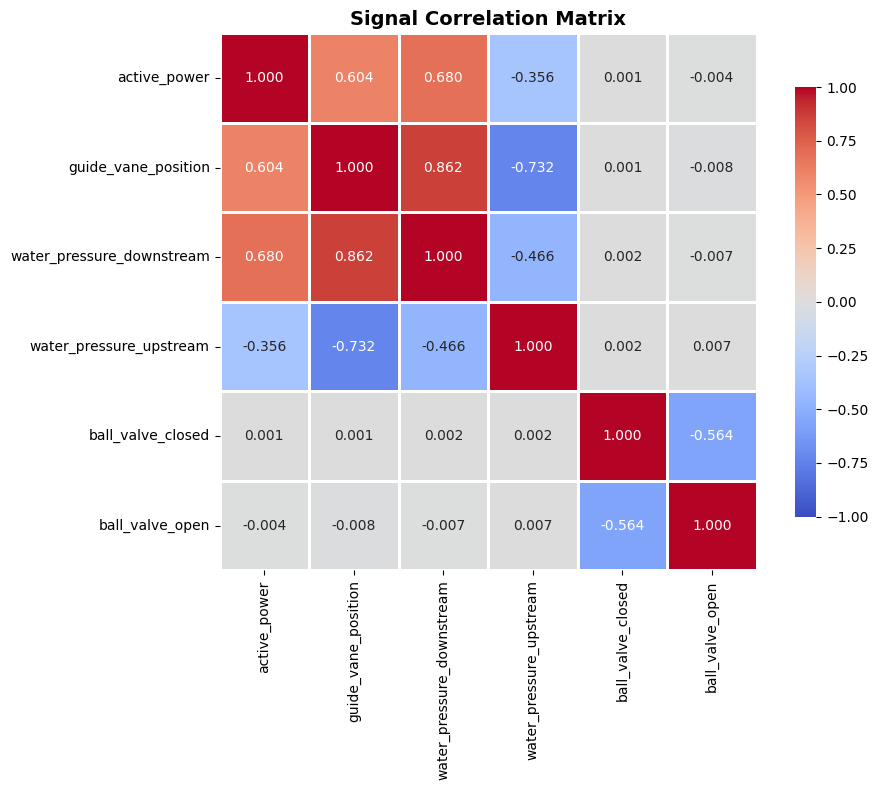

In [36]:
def create_correlation_matrix(res_pwr, res_vane, res_down, res_up, bin_closed, bin_open):
    """
    Create correlation matrix from signal segments
    
    Parameters:
    -----------
    res_pwr, res_vane, res_down, res_up : list of DataFrames
        Smoothed signal segments
    bin_closed, bin_open : list of DataFrames
        Binary signal segments
    
    Returns:
    --------
    DataFrame : Correlation matrix
    """
    # Collect all segments into one DataFrame
    all_data = []
    
    for i in range(len(res_pwr)):
        # Extract values from each segment
        segment_data = {
            'active_power': res_pwr[i]['value'].values,
            'guide_vane_position': res_vane[i]['value'].values,
            'water_pressure_downstream': res_down[i]['value'].values,
            'water_pressure_upstream': res_up[i]['value'].values,
            'ball_valve_closed': bin_closed[i]['value'].values,
            'ball_valve_open': bin_open[i]['value'].values,
        }
        
        # Find minimum length (in case segments have different lengths)
        min_len = min(len(v) for v in segment_data.values())
        
        # Truncate all to same length
        segment_data = {k: v[:min_len] for k, v in segment_data.items()}
        
        # Create DataFrame for this segment
        df_segment = pd.DataFrame(segment_data)
        all_data.append(df_segment)
    
    # Concatenate all segments
    df_combined = pd.concat(all_data, ignore_index=True)
    
    # Calculate correlation matrix
    corr_matrix = df_combined.corr()
    
    return corr_matrix, df_combined

# Create correlation matrix
corr_matrix, df_combined = create_correlation_matrix(
    res_pwr, res_vane, res_down, res_up, bin_closed, bin_open
)

# Display correlation matrix
print("Correlation Matrix:")
print(corr_matrix)

# Visualize with heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', vmin=-1, vmax=1)
plt.title('Signal Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()